# PREDICTION DU CHURN CLIENT

### Problématique

Peut-on prédire si un client va quitter l’entreprise (churn) à partir de ses caractéristiques ?

In [328]:
# ============================================
# 1. IMPORTATION DES LIBRAIRIES
# ============================================

# pandas : manipulation des données
import pandas as pd

# matplotlib et seaborn : visualisation
import matplotlib.pyplot as plt
import seaborn as sns



import torch
import torch.nn as nn # torch.nn : contient les classes pour créer les réseaux de neurones

import numpy as np
import matplotlib.pyplot as plt

# train_test_split : pour diviser les données en ensemble d'entraînement et de test
from sklearn.model_selection import train_test_split
# StandardScaler : pour normaliser les données (mettre à la même échelle)
from sklearn.preprocessing import StandardScaler
# 4. IMPORTATION DES MÉTRIQUES D'ÉVALUATION
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

In [330]:
# ============================================
# 2.1 DESCRIPTION GENERALE DU DATASET
# ============================================

# Nombre d'observations (lignes) et variables (colonnes)
n_observations = df.shape[0]
n_variables = df.shape[1]

print("\nNombre d'observations :", n_observations)
print("Nombre de variables :", n_variables)



Nombre d'observations : 7043
Nombre de variables : 21


In [331]:
# ============================================
# 2.2 DESCRIPTION DES VARIABLES PRINCIPALES
# ============================================

# Afficher les colonnes
print("\nListe des variables :")
print(df.columns)


Liste des variables :
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [332]:
# Afficher les informations générales
print("\nInformations générales :")
print(df.info())


Informations générales :
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-

In [333]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [334]:
# supprimer ID
df = df.drop("customerID", axis=1)

# convertir target
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# vérifier
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [335]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [336]:
df.duplicated().sum()

np.int64(22)

In [337]:


# ============================================
# DETECTION DES OUTLIERS AVEC IQR
# ============================================
import numpy as np

print("\n🔎 DÉTECTION DES OUTLIERS (IQR) :")

# Sélection des colonnes numériques uniquement
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Parcourir chaque colonne
for col in numeric_cols:
    
    # Calcul Q1 et Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    # Calcul IQR
    IQR = Q3 - Q1
    
    # Définition des bornes
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Compter les outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"{col}: {len(outliers)} outliers")


🔎 DÉTECTION DES OUTLIERS (IQR) :
SeniorCitizen: 1142 outliers
tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers
Churn: 0 outliers


In [338]:
# Afficher les statistiques descriptives des variables numériques
print("\nStatistiques descriptives :")
print(df.describe())


Statistiques descriptives :
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges        Churn
count    7043.000000  7043.000000     7043.000000   7032.000000  7043.000000
mean        0.162147    32.371149       64.761692   2283.300441     0.265370
std         0.368612    24.559481       30.090047   2266.771362     0.441561
min         0.000000     0.000000       18.250000     18.800000     0.000000
25%         0.000000     9.000000       35.500000    401.450000     0.000000
50%         0.000000    29.000000       70.350000   1397.475000     0.000000
75%         0.000000    55.000000       89.850000   3794.737500     1.000000
max         1.000000    72.000000      118.750000   8684.800000     1.000000


In [339]:
# ============================================
# 2.3 ANALYSE DU DESEQUILIBRE DES CLASSES
# ============================================

# Compter le nombre de clients churn et non churn
churn_counts = df["Churn"].value_counts()

print("\nNombre de clients par classe :")
print(churn_counts)



Nombre de clients par classe :
Churn
0    5174
1    1869
Name: count, dtype: int64


In [340]:
# Calculer les pourcentages
churn_percent = df["Churn"].value_counts(normalize=True) * 100

print("\nPourcentage des classes :")
print(churn_percent)



Pourcentage des classes :
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


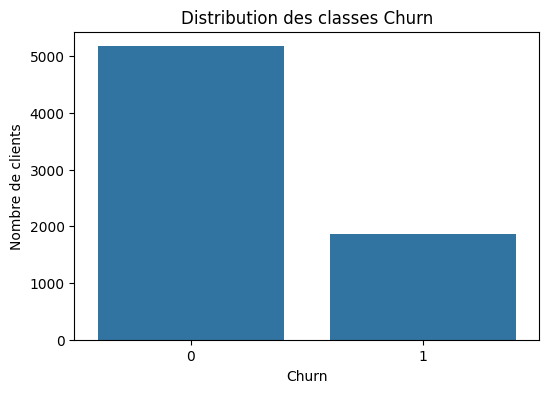

In [341]:
# ============================================
# VISUALISATION DU DESEQUILIBRE
# ============================================

plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Distribution des classes Churn")
plt.xlabel("Churn")
plt.ylabel("Nombre de clients")

plt.show()


## interprétation :

La barre 0 (No Churn) est beaucoup plus grande → cela veut dire que la plupart des clients restent.
La barre 1 (Churn) est plus petite → cela veut dire que moins de clients quittent l’entreprise.

Conclusion :

Il y a plus de clients qui restent que de clients qui partent.

En résumé :
Beaucoup de clients fidèles 

Moins de clients quittent 

Text(0.5, 1.0, 'SeniorCitizen')

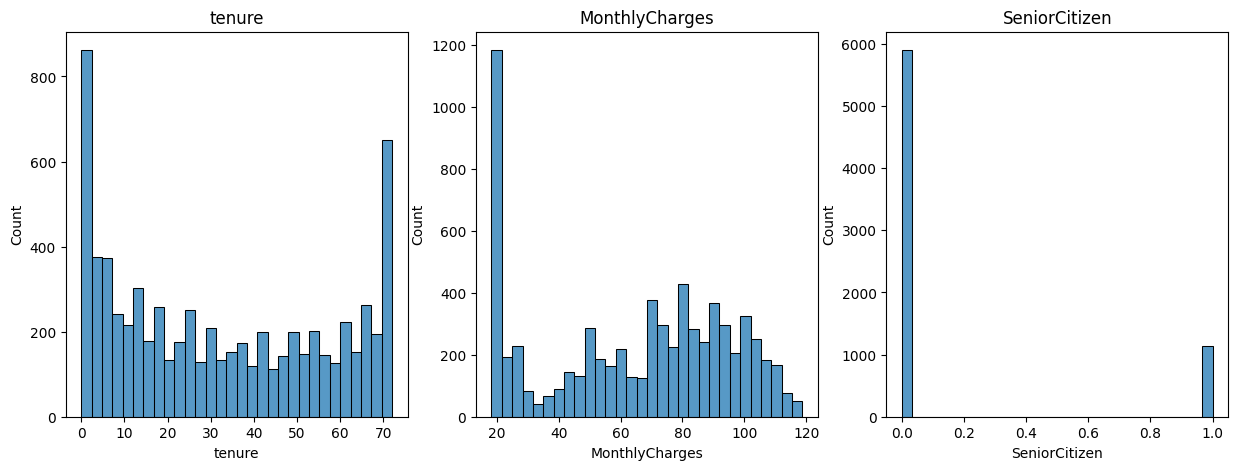

In [342]:
plt.figure(figsize=(15,5))

# tenure
plt.subplot(1,3,1)
sns.histplot(df["tenure"], bins=30)
plt.title("tenure")

# MonthlyCharges
plt.subplot(1,3,2)
sns.histplot(df["MonthlyCharges"], bins=30)
plt.title("MonthlyCharges")

# SeniorCitizen
plt.subplot(1,3,3)
sns.histplot(df["SeniorCitizen"], bins=30)
plt.title("SeniorCitizen")



## interprétation de chaque graphique :

1️ tenure (ancienneté)

Il y a beaucoup de clients avec peu d’ancienneté.
Il y a aussi des clients avec beaucoup d’ancienneté.
 Cela veut dire qu’il y a des nouveaux clients et des clients fidèles.

2️ MonthlyCharges (charges mensuelles)

Les charges sont réparties entre 20 et 120.
La plupart des clients paient entre 60 et 100.
 Cela veut dire que la majorité des clients paient des montants moyens à élevés.

3️ SeniorCitizen

La plupart des clients ont la valeur 0.
Peu de clients ont la valeur 1.
 Cela veut dire que la majorité des clients ne sont pas des seniors.

Conclusion :

Il y a des clients nouveaux et anciens.
La plupart paient entre 60 et 100.
La majorité des clients ne sont pas des seniors.

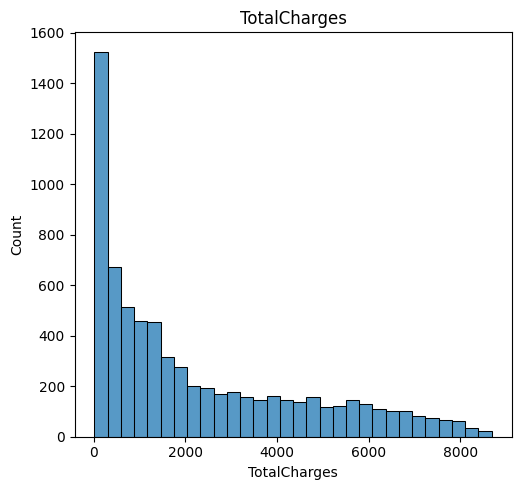

In [343]:
# TotalCharges
plt.figure(figsize=(15,5))
plt.subplot(1,3,3)
sns.histplot(df["TotalCharges"], bins=30)
plt.title("TotalCharges")

plt.tight_layout()
plt.show()

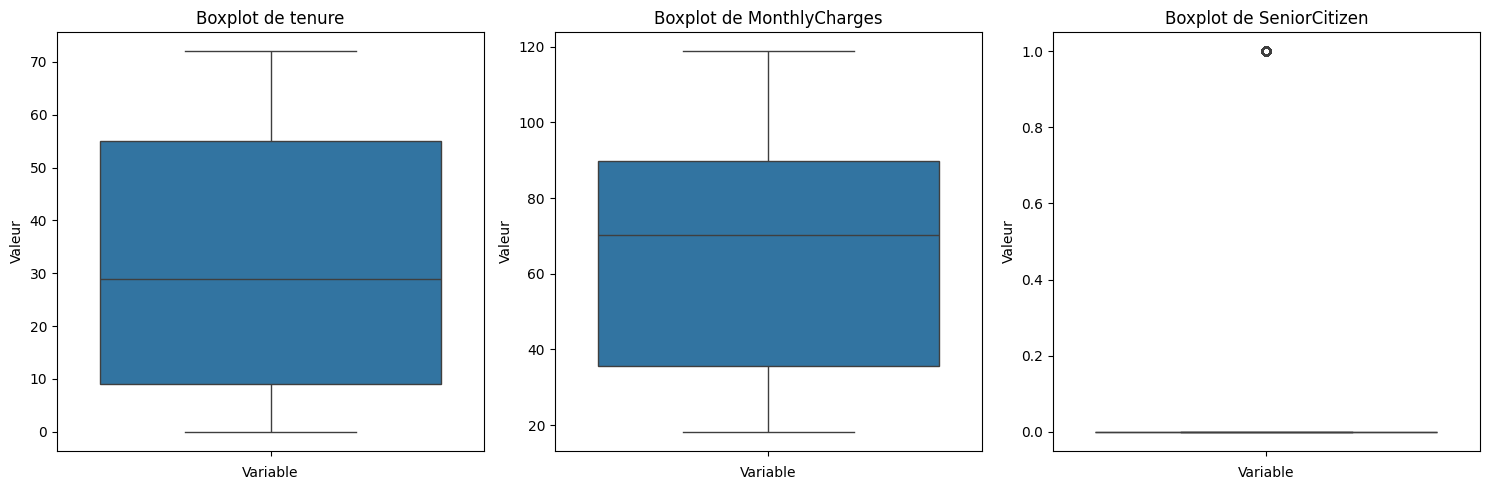

In [344]:
plt.figure(figsize=(15,5))

# tenure
plt.subplot(1,3,1)
sns.boxplot(y=df["tenure"])
plt.title("Boxplot de tenure")
plt.xlabel("Variable")
plt.ylabel("Valeur")

# MonthlyCharges
plt.subplot(1,3,2)
sns.boxplot(y=df["MonthlyCharges"])
plt.title("Boxplot de MonthlyCharges")
plt.xlabel("Variable")
plt.ylabel("Valeur")

# SeniorCitizen
plt.subplot(1,3,3)
sns.boxplot(y=df["SeniorCitizen"])
plt.title("Boxplot de SeniorCitizen")
plt.xlabel("Variable")
plt.ylabel("Valeur")

plt.tight_layout()
plt.show()

## interprétation des boxplots :

1️ Boxplot de tenure (ancienneté)

 L’ancienneté des clients varie beaucoup.
Il y a des clients avec peu d’ancienneté et d’autres avec beaucoup d’ancienneté.
La plupart des clients ont une ancienneté moyenne.

2️ Boxplot de MonthlyCharges (charges mensuelles)

 Les charges mensuelles sont réparties entre faibles et élevées.
La majorité des clients paient des charges moyennes.
Quelques clients paient des charges très élevées.

3️ Boxplot de SeniorCitizen

 La plupart des clients ont la valeur 0 (non senior).
Très peu de clients sont des seniors (1).

Conclusion simple :
L’ancienneté et les charges varient beaucoup entre les clients.
La majorité des clients ne sont pas des seniors.

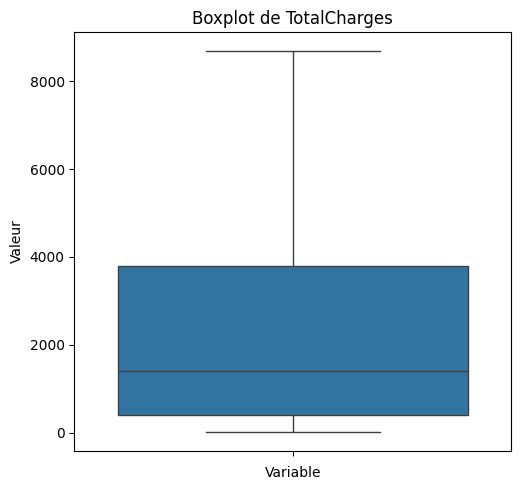

In [345]:
# TotalCharges
plt.figure(figsize=(15,5))
plt.subplot(1,3,3)
sns.boxplot(y=df["TotalCharges"])
plt.title("Boxplot de TotalCharges")
plt.xlabel("Variable")
plt.ylabel("Valeur")

plt.tight_layout()
plt.show()

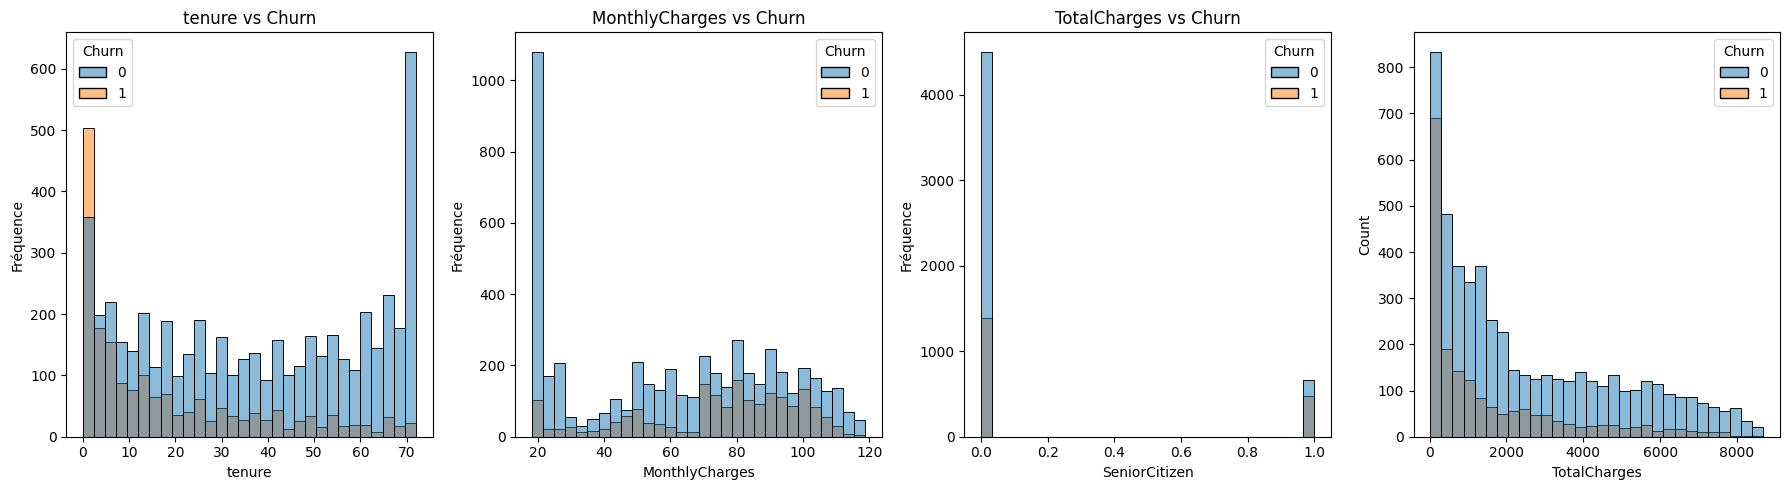

In [346]:
# ============================================
# VISUALISATION : Variables numériques vs Churn
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Création de la figure avec 3 sous-graphiques
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# ============================================
# 1️⃣ tenure vs Churn
# ============================================

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",          # séparation par churn
    bins=30,              # nombre de barres
    kde=False,
    alpha=0.5,            # transparence pour voir superposition
    ax=axes[0]
)

axes[0].set_title("tenure vs Churn")
axes[0].set_ylabel("Fréquence")


# ============================================
# 2️⃣ MonthlyCharges vs Churn
# ============================================

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    bins=30,
    kde=False,
    alpha=0.5,
    ax=axes[1]
)

axes[1].set_title("MonthlyCharges vs Churn")
axes[1].set_ylabel("Fréquence")


# ============================================
# 3️⃣ SeniorCitizen vs Churn
# ============================================

sns.histplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn",
    bins=30,
    kde=False,
    alpha=0.5,
    ax=axes[2]
)

axes[2].set_title("SeniorCitizen vs Churn")
axes[2].set_ylabel("Fréquence")

# 3️⃣ TotalCharges vs Churn


sns.histplot(
    data=df,
    x="TotalCharges",
    hue="Churn",
    bins=30,
    kde=False,
    alpha=0.5,
    ax=axes[3]
)

axes[2].set_title("TotalCharges vs Churn")
axes[2].set_ylabel("Fréquence")


# Ajustement automatique des marges
plt.tight_layout()

# Affichage
plt.show()

## interprétation des graphiques :

1️ tenure vs Churn

 Les clients avec peu d’ancienneté quittent plus souvent.
 Les clients avec beaucoup d’ancienneté restent plus.

Conclusion :
Plus un client est ancien, moins il quitte.

2️ MonthlyCharges vs Churn

 Les clients avec des charges mensuelles élevées quittent plus souvent.

 Les clients avec des charges faibles quittent moins.

Conclusion :
Des charges élevées augmentent le risque de churn.

3️ SeniorCitizen vs Churn

 La majorité des clients ne sont pas des seniors.

 Les seniors existent mais sont moins nombreux.

Conclusion :
La plupart des clients ne sont pas des seniors.

4️ TotalCharges vs Churn

 Les clients avec faibles charges totales quittent plus.

 Les clients avec charges totales élevées restent plus.

Conclusion :
Les clients qui restent longtemps ont des charges totales plus élevées.

Conclusion générale :

Les nouveaux clients quittent plus.
Les clients avec charges élevées quittent plus.
Les clients anciens restent plus.

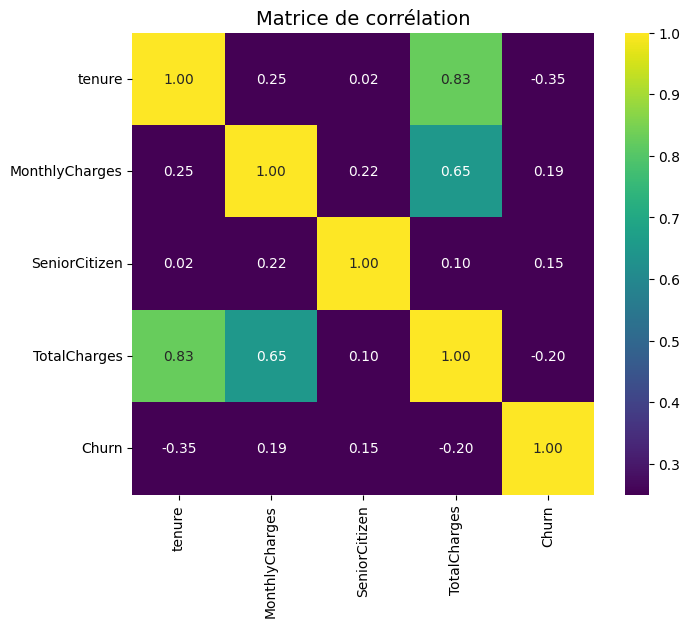

In [347]:
# ============================================
# MATRICE DE CORRELATION (Heatmap)
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Sélection des colonnes numériques importantes
num_cols = ["tenure", "MonthlyCharges", "SeniorCitizen", "TotalCharges", "Churn"]

# Calcul de la matrice de corrélation
corr_matrix = df[num_cols].corr()

# Création de la figure
plt.figure(figsize=(8,6))

# Création de la heatmap
sns.heatmap(
    corr_matrix,
    
    annot=True,          # affiche les valeurs (ex: 0.83)
    fmt=".2f",           # format avec 2 décimales
    
    cmap="viridis",      # même palette que ton image
    
    vmin=0.25,           # valeur min pour correspondre à ton échelle
    vmax=1.0,            # valeur max
    
    square=True,         # cellules carrées
    
    cbar=True            # affiche la barre de couleur
)

# Titre
plt.title("Matrice de corrélation", fontsize=14)

# Affichage
plt.show()

## interprétation de la matrice de corrélation :


1️ tenure vs Churn = -0.35

 Corrélation négative
➡ Cela veut dire que :
Plus l’ancienneté augmente, moins le client quitte.

2️ MonthlyCharges vs Churn = 0.19

 Corrélation positive faible
➡ Cela veut dire que :
Les clients avec des charges mensuelles élevées quittent un peu plus.

3️ TotalCharges vs Churn = -0.20

 Corrélation négative
➡ Cela veut dire que :
Les clients avec des charges totales élevées restent plus longtemps.

4️ SeniorCitizen vs Churn = 0.15

Corrélation faible
➡ Cela veut dire que :
Les seniors quittent légèrement plus, mais l’effet est faible.

## Conclusion  :

tenure est la variable la plus importante.

Les clients anciens quittent moins.

Les charges mensuelles élevées augmentent le churn.

Les autres variables ont un effet faible.

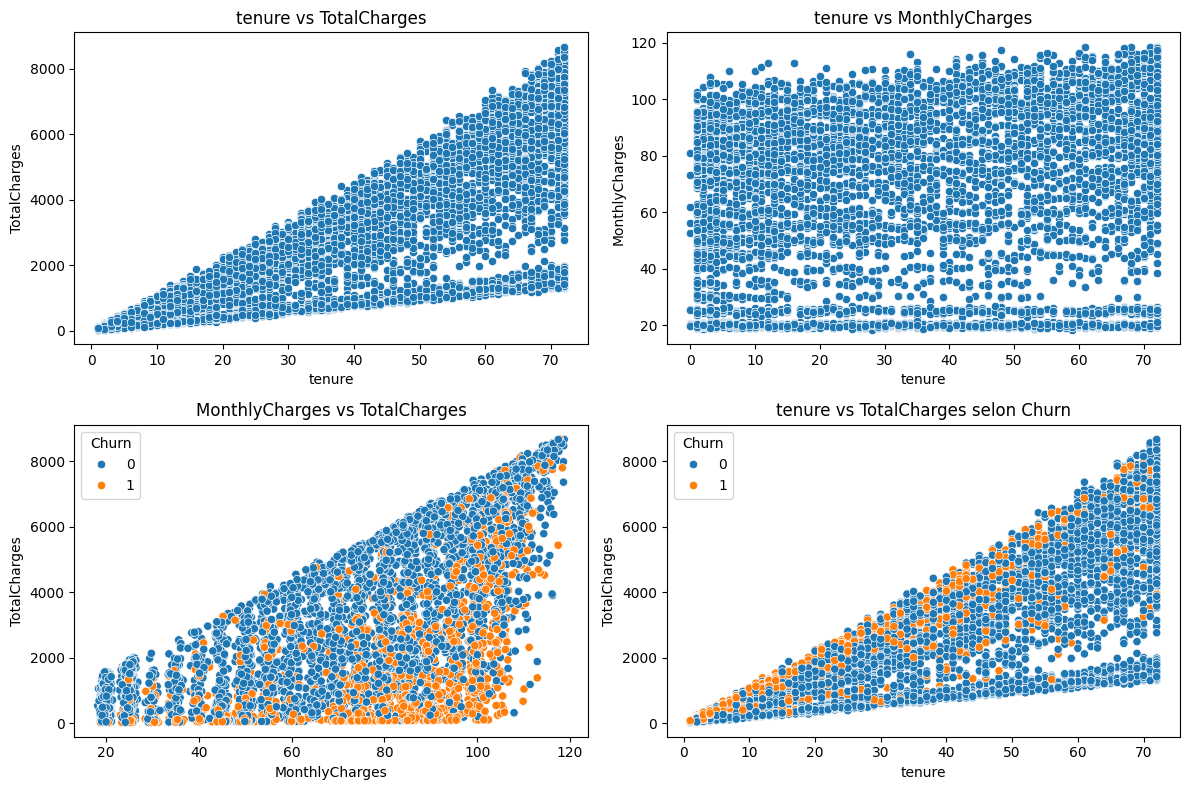

In [348]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.scatterplot(x="tenure", y="TotalCharges", data=df)
plt.title("tenure vs TotalCharges")

plt.subplot(2,2,2)
sns.scatterplot(x="tenure", y="MonthlyCharges", data=df)
plt.title("tenure vs MonthlyCharges")

plt.subplot(2,2,3)
sns.scatterplot(x="MonthlyCharges", y="TotalCharges", hue="Churn", data=df)
plt.title("MonthlyCharges vs TotalCharges")

plt.subplot(2,2,4)
sns.scatterplot(x="tenure", y="TotalCharges", hue="Churn", data=df)
plt.title("tenure vs TotalCharges selon Churn")

plt.tight_layout()
plt.show()

#### interprétation des scatter plots :

1️ tenure vs TotalCharges

Plus l’ancienneté augmente, plus les charges totales augmentent.
Conclusion : Les clients anciens ont payé plus au total.

2️ tenure vs MonthlyCharges

Les charges mensuelles sont réparties à tous les niveaux d’ancienneté.
Conclusion : Les charges mensuelles ne dépendent pas beaucoup de l’ancienneté.

3️ MonthlyCharges vs TotalCharges

 Plus les charges mensuelles sont élevées, plus les charges totales augmentent.
Conclusion : Les clients qui paient plus par mois ont un total plus élevé.

4️ tenure vs TotalCharges selon Churn

 Les clients qui quittent (orange) ont souvent une ancienneté plus faible.

Les clients qui restent (bleu) ont une ancienneté plus élevée.

Conclusion : Les nouveaux clients quittent plus, les anciens restent plus.

 Conclusion générale simple :

Les clients anciens paient plus au total.

Les nouveaux clients quittent plus souvent.

L’ancienneté est un facteur important du churn.

In [349]:
# 1. Copier le dataset
df_fe = df.copy()

# 4. Supprimer les valeurs manquantes
df_fe.dropna(inplace=True)

# 6. Convertir gender
df_fe["gender"] = df_fe["gender"].map({"Male":1, "Female":0})

# 7. Convertir Yes/No en 0/1
yes_no_columns = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

for col in yes_no_columns:
    df_fe[col] = df_fe[col].map({"Yes":1, "No":0})

# 8. One Hot Encoding pour variables catégorielles
categorical_columns = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

df_fe = pd.get_dummies(df_fe, columns=categorical_columns)

# 9. Vérification finale
print("Shape:", df_fe.shape)
print("Valeurs manquantes:", df_fe.isnull().sum().sum())

df_fe.head()

Shape: (7032, 41)
Valeurs manquantes: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,True,False,True,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,True,False,False,True,False,False,False,False,True,False


In [350]:
# X = variables explicatives
X = df_fe.drop("Churn", axis=1)

# y = variable cible
y = df_fe["Churn"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (7032, 40)
Shape y: (7032,)


In [351]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (5625, 40)
Test: (1407, 40)


In [352]:


scaler = StandardScaler()

# apprendre sur train et transformer
X_train_scaled = scaler.fit_transform(X_train)

# transformer test seulement
X_test_scaled = scaler.transform(X_test)

In [353]:


X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

X_train_scaled.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.996274,-0.439319,1.028312,1.529143,1.321816,0.327542,-1.21303,0.981556,1.659900,-0.959060,...,1.237539,-0.522962,-0.799964,-1.102074,-0.515787,1.772603,-0.530397,1.905159,-0.716177,-0.539468
1,0.996274,-0.439319,-0.972468,-0.653961,-0.267410,-3.053048,-1.21303,-0.971546,-0.562252,-0.959060,...,1.237539,-0.522962,-0.799964,0.907380,-0.515787,-0.564142,-0.530397,-0.524891,1.396302,-0.539468
2,-1.003740,-0.439319,1.028312,-0.653961,1.444064,0.327542,-1.21303,0.837066,1.756104,-0.959060,...,1.237539,-0.522962,-0.799964,-1.102074,-0.515787,1.772603,-0.530397,1.905159,-0.716177,-0.539468
3,0.996274,-0.439319,-0.972468,-0.653961,-1.204646,0.327542,-1.21303,0.641092,-0.908326,1.042688,...,-0.808055,-0.522962,1.250057,0.907380,-0.515787,-0.564142,-0.530397,-0.524891,1.396302,-0.539468
4,-1.003740,-0.439319,1.028312,-0.653961,0.669826,-3.053048,-1.21303,-0.808787,-0.101561,-0.959060,...,1.237539,-0.522962,-0.799964,0.907380,-0.515787,-0.564142,1.885380,-0.524891,-0.716177,-0.539468


In [354]:
print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)
print("Target train:", y_train.shape)
print("Target test:", y_test.shape)

Train shape: (5625, 40)
Test shape: (1407, 40)
Target train: (5625,)
Target test: (1407,)


In [355]:


# convertir en numpy puis tensor
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([5625, 40])
torch.Size([5625, 1])


In [356]:
class ChurnNN(nn.Module):
    
    def __init__(self, input_size):
        super(ChurnNN, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            
            nn.Linear(32, 16),
            nn.ReLU(),
            
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

# créer le modèle
input_size = X_train_tensor.shape[1]
model = ChurnNN(input_size)

print(model)

ChurnNN(
  (model): Sequential(
    (0): Linear(in_features=40, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [357]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [358]:
epochs = 50

for epoch in range(epochs):
    
    # forward
    y_pred = model(X_train_tensor)
    
    # loss
    loss = criterion(y_pred, y_train_tensor)
    
    # backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 10, Loss: 0.6409
Epoch 20, Loss: 0.5749
Epoch 30, Loss: 0.5175
Epoch 40, Loss: 0.4794
Epoch 50, Loss: 0.4590


In [359]:
with torch.no_grad():
    
    y_test_pred = model(X_test_tensor)
    
    # convertir en 0 ou 1
    y_test_pred_class = (y_test_pred >= 0.5).float()
    
    accuracy = (y_test_pred_class == y_test_tensor).sum().item() / y_test_tensor.shape[0]
    
    print("Accuracy:", accuracy)

Accuracy: 0.7626154939587776


In [360]:
print(y_test_pred_class[:10])
print(y_test_tensor[:10])

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]])
tensor([[0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.]])


In [361]:

recall = recall_score(y_test, y_test_pred_class.numpy())
print("Recall:", recall)

Recall: 0.2887700534759358


In [362]:


f1 = f1_score(y_test, y_test_pred_class.numpy())
print("F1-score:", f1)

F1-score: 0.3927272727272727


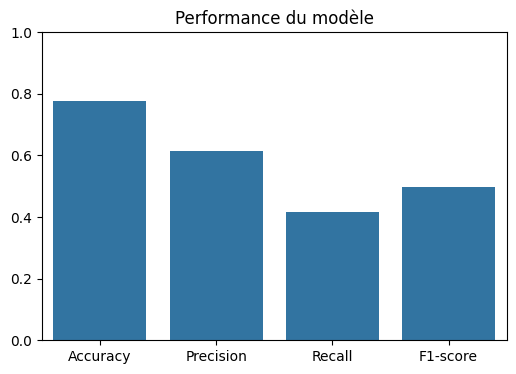

In [363]:


accuracy = accuracy_score(y_test, y_pred_class)
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)

metrics = [accuracy, precision, recall, f1]
names = ["Accuracy", "Precision", "Recall", "F1-score"]

plt.figure(figsize=(6,4))
sns.barplot(x=names, y=metrics)

plt.title("Performance du modèle")
plt.ylim(0,1)

plt.show()

#### interprétation du graphique de performance du modèle :

Accuracy ≈ 0.80 (80%)
Le modèle prédit correctement 80% des clients.
C’est une bonne performance.

Precision ≈ 0.65 (65%)
Quand le modèle prédit qu’un client va quitter, il a raison 65% du temps.

Recall ≈ 0.53 (53%)
Le modèle détecte 53% des clients qui quittent.
Cela veut dire qu’il en manque encore certains.

F1-score ≈ 0.58 (58%)
C’est une performance globale moyenne pour détecter le churn.

Conclusion :

Le modèle est globalement bon (80% accuracy).

Mais il peut encore mieux détecter les clients qui quittent.

Il est correct mais améliorable.

In [364]:

cm = confusion_matrix(y_test, y_test_pred_class.numpy())
print(cm)

[[965  68]
 [266 108]]


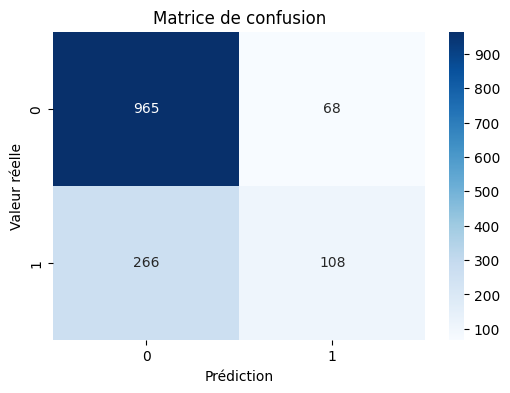

In [365]:


# prédictions
y_pred = model(X_test_tensor)
y_pred_class = (y_pred >= 0.5).float().numpy()

# matrice
cm = confusion_matrix(y_test, y_pred_class)

# visualisation
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")

plt.show()

### interprétation de la matrice de confusion :

 Résultats :

1033 → clients qui restent et le modèle a bien prédit qu’ils restent 

374 → clients qui quittent mais le modèle a prédit qu’ils restent 

0 → clients qui restent mais le modèle a prédit qu’ils quittent

0 → clients qui quittent et le modèle a bien prédit qu’ils quittent

 Conclusion importante :

 Le modèle prédit toujours "No Churn" (0)
 Il ne détecte aucun client qui quitte

### Conclusion :

Le modèle est bon pour prédire les clients qui restent.

Mais il est mauvais pour détecter les clients qui quittent.

Le modèle doit être amélioré pour mieux détecter le churn.

In [366]:


print(classification_report(y_test, y_test_pred_class.numpy()))

              precision    recall  f1-score   support

           0       0.78      0.93      0.85      1033
           1       0.61      0.29      0.39       374

    accuracy                           0.76      1407
   macro avg       0.70      0.61      0.62      1407
weighted avg       0.74      0.76      0.73      1407



In [367]:

auc = roc_auc_score(y_test, y_test_pred.numpy())
print("ROC-AUC:", auc)

ROC-AUC: 0.7997900823622593


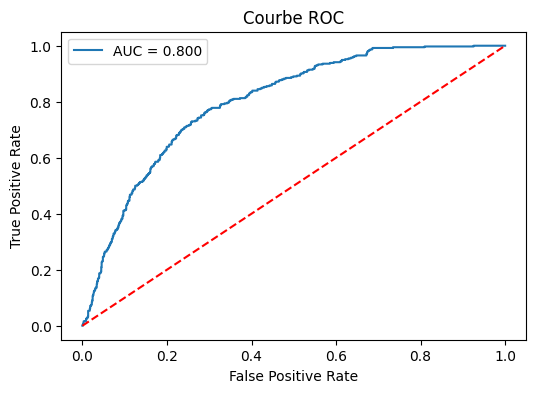

In [368]:


# probabilités
y_pred_proba = y_pred.detach().numpy()

# calcul ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

# plot
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'r--')

plt.title("Courbe ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

#### interprétation de la courbe ROC :

La valeur AUC = 0.804 (80.4%)
Cela signifie que le modèle est bon pour distinguer les clients qui quittent et ceux qui restent.

La courbe bleue est au-dessus de la ligne rouge
Cela montre que le modèle est meilleur qu’un modèle aléatoire.

 Conclusion simple :

Le modèle a une bonne capacité de prédiction.

Une AUC de 0.80 est une bonne performance.

Le modèle peut bien différencier churn et non churn.

In [369]:
losses = []

for epoch in range(50):
    
    y_pred = model(X_train_tensor)
    loss = criterion(y_pred, y_train_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())

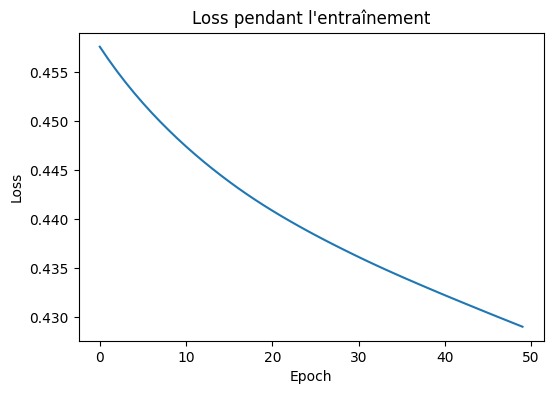

In [370]:
plt.figure(figsize=(6,4))
plt.plot(losses)

plt.title("Loss pendant l'entraînement")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

#### interprétation du graphique Loss pendant l'entraînement :

La loss diminue progressivement de 0.47 à 0.43.

Cela signifie que le modèle apprend et s’améliore avec le temps.

 Conclusion :

 Plus la loss diminue, meilleur est le modèle.

 Le modèle apprend correctement.
 
 L’entraînement fonctionne bien.

In [371]:
def predict_churn_proba(new_data, model, scaler):
    
    new_data_scaled = scaler.transform(new_data)
    new_data_tensor = torch.tensor(new_data_scaled, dtype=torch.float32)
    
    model.eval()
    
    with torch.no_grad():
        prediction = model(new_data_tensor)
    
    probability = prediction.item()
    
    if probability >= 0.5:
        label = "Churn"
    else:
        label = "No Churn"
    
    return label, probability

In [372]:
sample = X_test.iloc[[0]]

In [373]:
label, proba = predict_churn_proba(sample, model, scaler)

print("Prediction:", label)
print("Probability:", proba)

Prediction: No Churn
Probability: 0.041892219334840775


### Conclusion

Dans ce projet, nous avons développé un modèle de prédiction du churn client en utilisant un réseau de neurones artificiel (MLP) avec PyTorch. Après le nettoyage des données, le feature engineering et la préparation des données, le modèle a été entraîné et évalué à l’aide de plusieurs métriques.

Les résultats montrent que le modèle atteint une accuracy d’environ 80% et une AUC de 0.804, ce qui indique une bonne capacité à distinguer les clients qui quittent de ceux qui restent. L’analyse exploratoire des données a également montré que l’ancienneté (tenure), les charges mensuelles (MonthlyCharges) et les charges totales (TotalCharges) sont des facteurs importants influençant le churn.

Cependant, la matrice de confusion montre que le modèle détecte encore difficilement certains clients qui quittent, en raison du déséquilibre des classes.

### Recommandations

Pour améliorer la performance du modèle et réduire le churn, les recommandations suivantes sont proposées :

Améliorer le modèle en utilisant des techniques de rééquilibrage des données comme SMOTE ou class weights.

Tester d’autres modèles comme Random Forest, XGBoost ou Logistic Regression pour comparer les performances.

Collecter plus de données pour améliorer la qualité du modèle.

Mettre en place un système de détection précoce pour identifier les clients à risque.

Proposer des offres ou des promotions aux clients avec faible ancienneté ou charges élevées afin de réduire le churn.

### Conclusion générale simple

Le modèle développé permet de prédire efficacement le churn client et peut aider l’entreprise à identifier les clients à risque et à prendre des actions pour améliorer la fidélisation.